# Notebook 8: Ensemble Learning – Random Forests & Bagging
**Part 8/30 – ML Mastery Series for Python Experts**

---

Welcome back. You've seen how decision trees carve up feature space with ruthless efficiency—and how they overfit with equal ruthlessness. This notebook dives into **ensemble learning**, where we turn that instability into an asset. You'll learn how **bagging** (bootstrap aggregating) tames variance by averaging many noisy trees, and how **Random Forest** adds an extra layer of randomness to build robust, generalizable models. By the end, you'll be using out-of-bag scores as free validation and interpreting feature importance like a pro.

## Why Single Trees Are Unstable – Motivation for Ensembles

Decision trees are powerful but fragile. Here's why we need ensembles:

- **High variance**: Small changes in training data → dramatically different tree structures
- **Instability**: Adding/removing a few samples can flip splits near the root, cascading changes throughout
- **Axis-aligned splits**: Create sharp, jagged decision boundaries that don't generalize well
- **Greedy optimization**: Each split is locally optimal but globally myopic; trees chase noise in training data
- **Overfitting depth**: Without aggressive pruning, trees memorize training patterns including random noise
- **No smoothness**: Predictions jump discontinuously at split boundaries
- **The ensemble insight**: Averaging many high-variance, low-bias learners → strong, smooth model with lower variance (bias-variance tradeoff in action)

*Key intuition*: Individual trees are "weak learners" in the sense that they're unstable, but averaging hundreds of them cancels out the noise while preserving the signal.

## Learning Objectives

By the end of this notebook, you will:

- **Understand bagging**: Bootstrap sampling + aggregation formula and why it reduces variance as $\frac{\sigma^2}{B}$ for $B$ independent trees
- **Implement bagging manually**: Resample with replacement, fit multiple trees, aggregate predictions via soft voting
- **Compare stability**: Visualize how single trees overfit wildly while bagged ensembles produce smooth, stable boundaries
- **Grasp Random Forest's extra randomness**: Feature subsampling (`max_features`) decorrelates trees further
- **Leverage OOB evaluation**: Use out-of-bag samples as a free validation set without sacrificing training data
- **Tune key hyperparameters**: Know how `n_estimators`, `max_features`, `max_depth`, and `min_samples_leaf` interact
- **Interpret feature importance**: Distinguish between impurity-based importance and permutation importance
- **Apply to regression**: See how RandomForestRegressor handles continuous targets with the same ensemble principles

## 1. Bagging Basics – Manual Demonstration on Toy Data

Let's start from scratch. We'll generate noisy moon-shaped data, fit a single decision tree, then manually implement bagging by bootstrapping 15 times and averaging predictions. Watch how the decision boundary smooths out.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns

# Set plotting style
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Generate noisy moons data
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit single decision tree
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

print(f"Single tree train accuracy: {single_tree.score(X_train, y_train):.3f}")
print(f"Single tree test accuracy: {single_tree.score(X_test, y_test):.3f}")

Single tree train accuracy: 1.000
Single tree test accuracy: 0.853


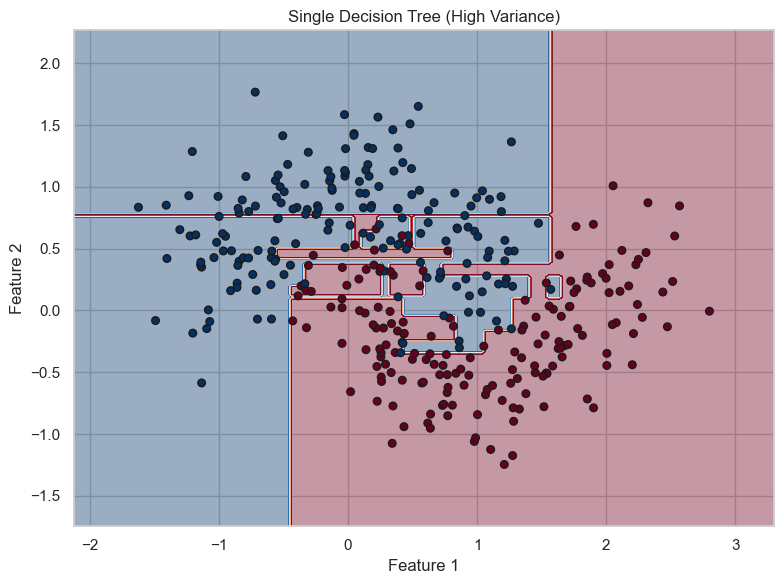

In [2]:
def plot_decision_boundary(clf, X, y, title, ax=None, alpha=0.4):
    """Plot decision boundary for 2D classifier."""
    if ax is None:
        ax = plt.gca()
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z, levels=50, alpha=alpha, cmap='RdBu_r')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolors='k', s=30)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Plot single tree boundary
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_decision_boundary(single_tree, X_train, y_train, 'Single Decision Tree (High Variance)', ax=ax)
plt.tight_layout()
plt.show()

In [3]:
# Manual bagging: bootstrap 15 trees and average predictions
np.random.seed(42)
n_estimators = 15
n_samples = len(X_train)
trees = []

# Bootstrap sampling: sample with replacement, fit tree on each bootstrap sample
for i in range(n_estimators):
    # Generate bootstrap indices
    bootstrap_idx = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train[bootstrap_idx]
    y_boot = y_train[bootstrap_idx]
    
    # Fit tree on bootstrap sample
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_boot, y_boot)
    trees.append(tree)

print(f"Fitted {len(trees)} trees on bootstrap samples")

Fitted 15 trees on bootstrap samples


In [4]:
class ManualBaggingClassifier:
    """Simple bagging classifier using soft voting (probability averaging)."""
    def __init__(self, trees):
        self.trees = trees
    
    def predict_proba(self, X):
        # Average probabilities across all trees (soft voting)
        probs = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(probs, axis=0)
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Create manual bagging ensemble
manual_bag = ManualBaggingClassifier(trees)
print(f"Manual bagging train accuracy: {manual_bag.score(X_train, y_train):.3f}")
print(f"Manual bagging test accuracy: {manual_bag.score(X_test, y_test):.3f}")

Manual bagging train accuracy: 0.986
Manual bagging test accuracy: 0.880


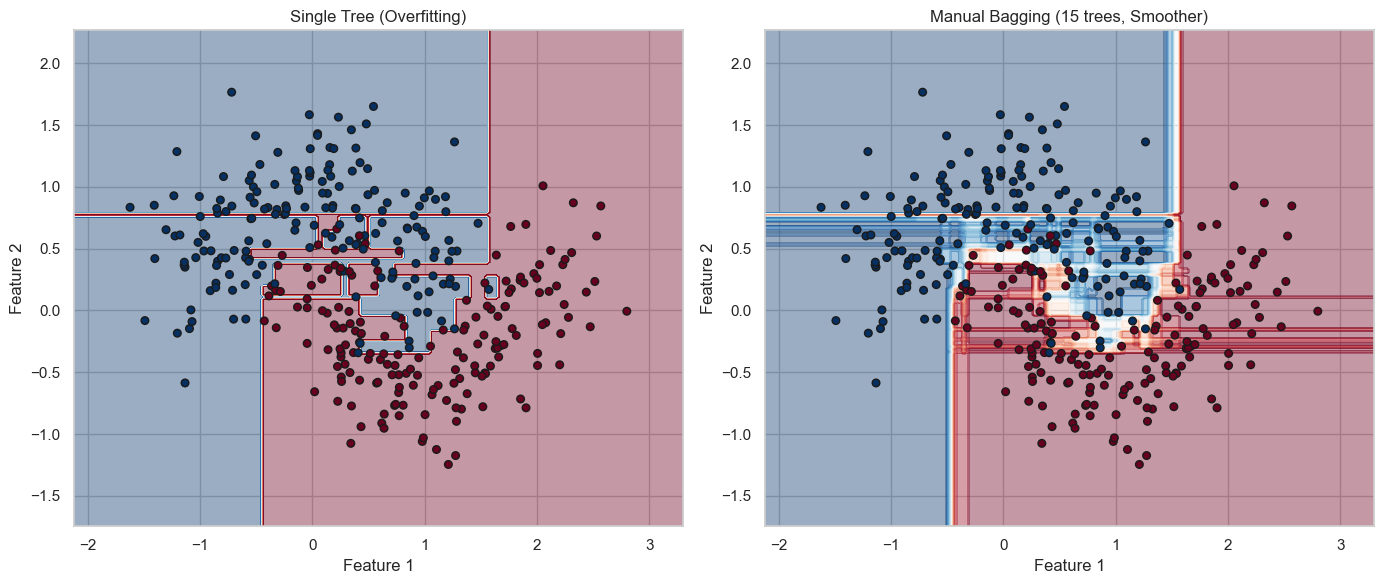

In [5]:
# Compare boundaries: single tree vs manual bagging
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(single_tree, X_train, y_train, 
                       'Single Tree (Overfitting)', ax=axes[0])
plot_decision_boundary(manual_bag, X_train, y_train, 
                       f'Manual Bagging ({n_estimators} trees, Smoother)', ax=axes[1])

plt.tight_layout()
plt.show()

# Notice: Single tree has jagged, irregular boundary chasing noise
# Bagging produces smoother, more natural moon-shaped boundary

## 2. Using BaggingClassifier / BaggingRegressor

Now let's use sklearn's production-ready `BaggingClassifier`. We'll compare it with single trees and demonstrate variance reduction by fitting multiple baggers with different random seeds.

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Production bagging classifier with 100 trees
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # Base estimator
    n_estimators=100,                   # Number of bootstrap samples
    max_samples=1.0,                    # Use 100% of training data (with replacement)
    bootstrap=True,                     # Sample with replacement (True = bagging, False = pasting)
    random_state=42,
    n_jobs=-1                           # Parallelize across all cores
)

bagging_clf.fit(X_train, y_train)

print(f"Bagging (100 trees) train accuracy: {bagging_clf.score(X_train, y_train):.3f}")
print(f"Bagging (100 trees) test accuracy: {bagging_clf.score(X_test, y_test):.3f}")
print(f"Single tree test accuracy: {single_tree.score(X_test, y_test):.3f}")
print(f"\nImprovement: +{(bagging_clf.score(X_test, y_test) - single_tree.score(X_test, y_test)):.3f}")

Bagging (100 trees) train accuracy: 1.000
Bagging (100 trees) test accuracy: 0.900
Single tree test accuracy: 0.853

Improvement: +0.047


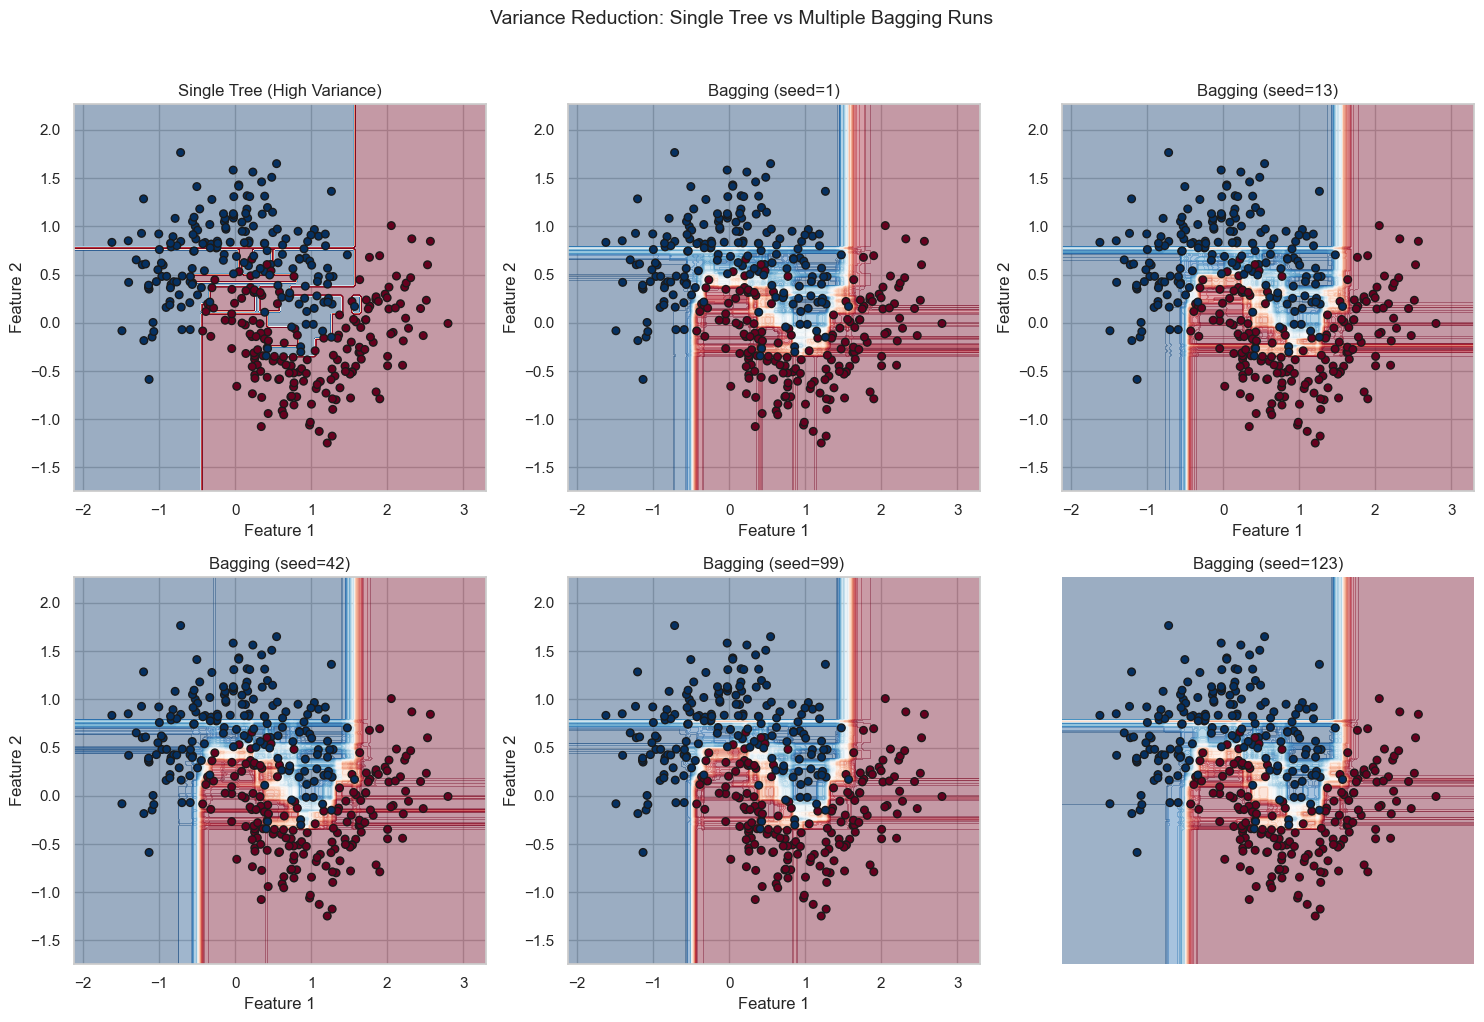

In [7]:
# Demonstrate variance reduction: fit 5 different baggers with different seeds
seeds = [1, 13, 42, 99, 123]
baggers = []

for seed in seeds:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,  # Fewer trees for faster plotting
        bootstrap=True,
        random_state=seed,
        n_jobs=-1
    )
    bag.fit(X_train, y_train)
    baggers.append(bag)

# Plot boundaries of different bagging runs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Plot single tree first
plot_decision_boundary(single_tree, X_train, y_train, 
                       'Single Tree (High Variance)', ax=axes[0])

# Plot 5 different bagging runs
for idx, (bag, seed) in enumerate(zip(baggers, seeds), 1):
    plot_decision_boundary(bag, X_train, y_train, 
                          f'Bagging (seed={seed})', ax=axes[idx])

axes[-1].axis('off')  # Hide last subplot if odd number
plt.suptitle('Variance Reduction: Single Tree vs Multiple Bagging Runs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Observe: Single tree boundaries vary wildly with small data changes
# Bagging boundaries are remarkably stable across different random seeds

## 🌲 3. Introducing Random Forest – Extra Randomness

Random Forest extends bagging by adding **feature randomness**: at each split, only a random subset of features is considered. This decorrelates trees further, reducing variance even more than bagging alone. Let's compare RF vs Bagging on real datasets.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score

# Load wine dataset (multiclass classification)
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Compare Random Forest vs Bagging with same number of trees
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',  # Consider sqrt(n_features) at each split
    random_state=42,
    n_jobs=-1
)

bagging_clf_wine = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# 10-fold cross-validation
rf_scores = cross_val_score(rf_clf, X_wine, y_wine, cv=10, n_jobs=-1)
bag_scores = cross_val_score(bagging_clf_wine, X_wine, y_wine, cv=10, n_jobs=-1)

print(f"Random Forest CV accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Bagging CV accuracy: {bag_scores.mean():.4f} (+/- {bag_scores.std():.4f})")
print(f"\nRF advantage: +{(rf_scores.mean() - bag_scores.mean()):.4f}")
print(f"RF lower std: {(bag_scores.std() - rf_scores.std()):.4f} (more stable)")

Random Forest CV accuracy: 0.9833 (+/- 0.0255)
Bagging CV accuracy: 0.9611 (+/- 0.0434)

RF advantage: +0.0222
RF lower std: 0.0179 (more stable)


  max_features  mean_accuracy       std
0         None       0.944286  0.046387
1         sqrt       0.972063  0.017571
2         log2       0.972063  0.017571
3          0.3       0.972063  0.017571
4          0.5       0.966508  0.020747
5          0.8       0.955397  0.033255


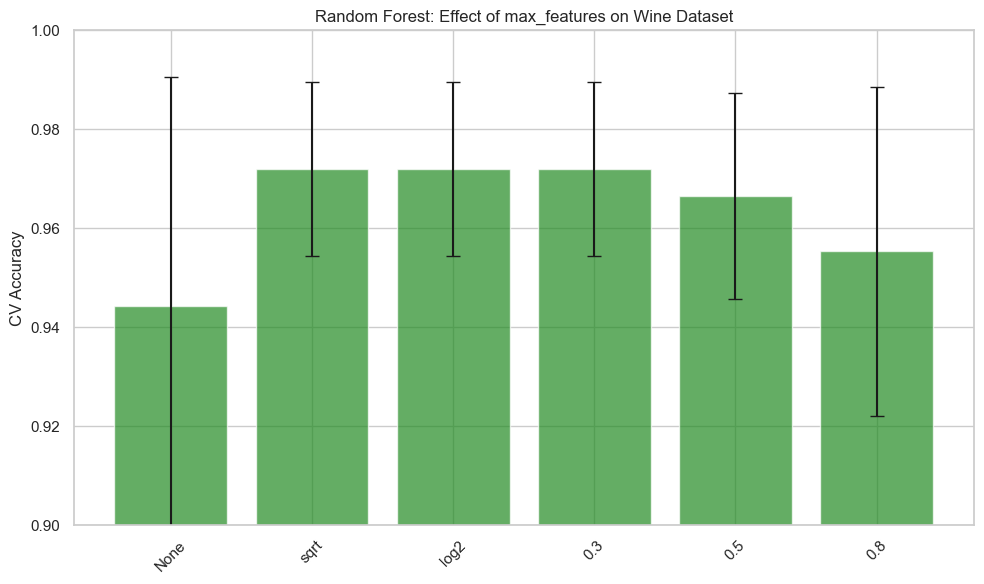

In [9]:
# Demonstrate effect of max_features parameter
max_features_options = [None, 'sqrt', 'log2', 0.3, 0.5, 0.8]
results = []

for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(rf, X_wine, y_wine, cv=5, n_jobs=-1)
    results.append({
        'max_features': str(mf),
        'mean_accuracy': scores.mean(),
        'std': scores.std()
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.bar(range(len(results_df)), results_df['mean_accuracy'], 
        yerr=results_df['std'], capsize=5, alpha=0.7, color='forestgreen')
plt.xticks(range(len(results_df)), results_df['max_features'], rotation=45)
plt.ylabel('CV Accuracy')
plt.title('Random Forest: Effect of max_features on Wine Dataset')
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

# Key insight: max_features='sqrt' (default) often strikes best balance
# None = all features = same as bagging, higher variance

## 4. Out-of-Bag (OOB) Evaluation – Free Validation

In bagging, each bootstrap sample leaves out ~37% of data (the "out-of-bag" samples). Random Forest can use these as a free validation set—no need for train/test split or cross-validation!

In [10]:
from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Split for comparison: we'll compare OOB vs hold-out vs CV
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Random Forest with OOB scoring enabled
rf_oob = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    oob_score=True,  # Enable OOB evaluation
    random_state=42,
    n_jobs=-1
)

rf_oob.fit(X_train_c, y_train_c)

# Compare scores
oob_score = rf_oob.oob_score_
test_score = rf_oob.score(X_test_c, y_test_c)
cv_scores = cross_val_score(rf_oob, X_cancer, y_cancer, cv=10)

print(f"OOB Score (free validation): {oob_score:.4f}")
print(f"Hold-out Test Score: {test_score:.4f}")
print(f"10-Fold CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\nOOB vs Test diff: {abs(oob_score - test_score):.4f}")
print(f"OOB vs CV diff: {abs(oob_score - cv_scores.mean()):.4f}")

# OOB is usually very close to both test and CV scores—amazing!

OOB Score (free validation): 0.9604
Hold-out Test Score: 0.9649
10-Fold CV Mean: 0.9631 (+/- 0.0288)

OOB vs Test diff: 0.0045
OOB vs CV diff: 0.0027


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


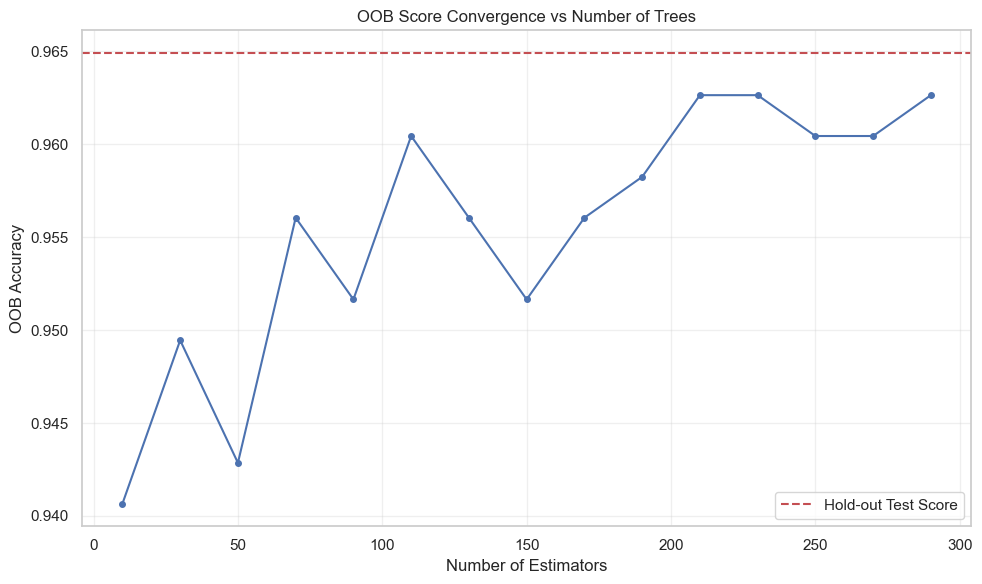

In [11]:
# Visualize OOB score convergence as n_estimators increases
oob_scores = []
estimator_range = range(10, 310, 20)

for n_est in estimator_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train_c, y_train_c)
    oob_scores.append(rf_temp.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(estimator_range, oob_scores, 'b-', marker='o', markersize=4)
plt.axhline(y=test_score, color='r', linestyle='--', label='Hold-out Test Score')
plt.xlabel('Number of Estimators')
plt.ylabel('OOB Accuracy')
plt.title('OOB Score Convergence vs Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# OOB score stabilizes around 100-200 trees—useful for early stopping!

## 5. Feature Importance & Interpretation

Random Forest provides built-in feature importance based on **mean decrease in impurity** (Gini importance). However, this can be biased toward high-cardinality features. Let's compare with **permutation importance**, which is more reliable.

In [ ]:
# Fit RF on breast cancer for feature importance
rf_importance = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_importance.fit(X_train_c, y_train_c)

# Built-in feature importance (impurity-based)
importances = rf_importance.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Top 10

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices], align='center', color='forestgreen', alpha=0.8)
plt.yticks(range(10), [cancer.feature_names[i] for i in indices])
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title('Top 10 Features – Built-in RF Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features by built-in importance:")
for i in range(5):
    print(f"{i+1}. {cancer.feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance: shuffle each feature and measure score drop
# More reliable but computationally expensive
perm_importance = permutation_importance(
    rf_importance, X_test_c, y_test_c, 
    n_repeats=10,  # Shuffle 10 times per feature for stability
    random_state=42,
    n_jobs=-1
)

perm_indices = np.argsort(perm_importance.importances_mean)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_importance.importances_mean[perm_indices], 
         xerr=perm_importance.importances_std[perm_indices],
         align='center', color='coral', alpha=0.8)
plt.yticks(range(10), [cancer.feature_names[i] for i in perm_indices])
plt.xlabel('Permutation Importance (Decrease in Accuracy)')
plt.title('Top 10 Features – Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features by permutation importance:")
for i in range(5):
    idx = perm_indices[i]
    print(f"{i+1}. {cancer.feature_names[idx]}: {perm_importance.importances_mean[idx]:.4f} (+/- {perm_importance.importances_std[idx]:.4f})")

In [ ]:
# Compare side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Built-in
axes[0].barh(range(10), importances[indices], color='forestgreen', alpha=0.8)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([cancer.feature_names[i] for i in indices])
axes[0].set_xlabel('Importance')
axes[0].set_title('Built-in (Impurity-based)')
axes[0].invert_yaxis()

# Permutation
axes[1].barh(range(10), perm_importance.importances_mean[perm_indices], 
            xerr=perm_importance.importances_std[perm_indices], color='coral', alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([cancer.feature_names[i] for i in perm_indices])
axes[1].set_xlabel('Importance')
axes[1].set_title('Permutation Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison: Built-in vs Permutation', fontsize=14)
plt.tight_layout()
plt.show()

# Note: Ranks are similar but not identical—permutation importance is preferred for final interpretation

## 6. Regression Example – RandomForestRegressor

Random Forest isn't just for classification. Let's apply it to regression using the California housing dataset and compare with single decision trees.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

# Load California housing (subset for speed if needed)
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Use subset for faster demonstration (first 5000 samples)
X_h = X_housing[:5000]
y_h = y_housing[:5000]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X_h.shape}")
print(f"Target range: [{y_h.min():.2f}, {y_h.max():.2f}]")

Dataset shape: (5000, 8)
Target range: [0.15, 5.00]


In [16]:
# Single Decision Tree Regressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_h, y_train_h)
y_pred_tree = tree_reg.predict(X_test_h)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_features=0.8,  # Use 80% of features per split
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_h, y_train_h)
y_pred_rf = rf_reg.predict(X_test_h)

# Compare metrics
tree_mse = mean_squared_error(y_test_h, y_pred_tree)
rf_mse = mean_squared_error(y_test_h, y_pred_rf)
tree_r2 = r2_score(y_test_h, y_pred_tree)
rf_r2 = r2_score(y_test_h, y_pred_rf)

print("=" * 50)
print("REGRESSION COMPARISON")
print("=" * 50)
print(f"Decision Tree  - MSE: {tree_mse:.4f}, R²: {tree_r2:.4f}")
print(f"Random Forest  - MSE: {rf_mse:.4f}, R²: {rf_r2:.4f}")
print(f"Improvement    - MSE: {((tree_mse - rf_mse)/tree_mse)*100:.1f}%, R²: +{(rf_r2 - tree_r2):.3f}")
print("=" * 50)

REGRESSION COMPARISON
Decision Tree  - MSE: 0.3964, R²: 0.6652
Random Forest  - MSE: 0.1792, R²: 0.8486
Improvement    - MSE: 54.8%, R²: +0.183


In [ ]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Single tree
axes[0].scatter(y_test_h, y_pred_tree, alpha=0.5, edgecolors='k', s=20)
axes[0].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title(f'Single Tree (R²={tree_r2:.3f})')
axes[0].set_xlim(0, 5)
axes[0].set_ylim(0, 5)

# Random Forest
axes[1].scatter(y_test_h, y_pred_rf, alpha=0.5, edgecolors='k', s=20, color='forestgreen')
axes[1].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price ($100k)')
axes[1].set_ylabel('Predicted Price ($100k)')
axes[1].set_title(f'Random Forest (R²={rf_r2:.3f})')
axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 5)

plt.suptitle('Actual vs Predicted: Single Tree vs Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# Notice: RF predictions cluster tighter around diagonal (better calibration)

In [ ]:
# Feature importance for regression
importances_reg = rf_reg.feature_importances_
indices_reg = np.argsort(importances_reg)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices_reg)), importances_reg[indices_reg], color='steelblue', alpha=0.8)
plt.yticks(range(len(indices_reg)), [housing.feature_names[i] for i in indices_reg])
plt.xlabel('Feature Importance')
plt.title('California Housing: Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature ranking:")
for i in range(len(indices_reg)):
    print(f"{i+1}. {housing.feature_names[indices_reg[i]]}: {importances_reg[indices_reg[i]]:.4f}")

## 7. Key Hyperparameters & Quick Tuning Demo

Random Forest has several critical hyperparameters. Let's explore their effects and do a quick randomized search.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define parameter distributions for random search
param_distributions = {
    'n_estimators': randint(50, 500),           # Number of trees
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # Features per split
    'max_depth': [None, 10, 20, 30, 40],        # Tree depth
    'min_samples_leaf': randint(1, 10),         # Min samples in leaf
    'bootstrap': [True, False]                  # Bootstrap vs pasting
}

# Quick randomized search (20 iterations, 3-fold CV)
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use wine dataset for tuning demo
rf_random.fit(X_wine, y_wine)

print(f"Best CV accuracy: {rf_random.best_score_:.4f}")
print(f"Best parameters:")
for param, value in rf_random.best_params_.items():
    print(f"  {param}: {value}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV accuracy: 0.9440
Best parameters:
  bootstrap: True
  max_depth: 40
  max_features: 0.5
  min_samples_leaf: 8
  n_estimators: 201


In [ ]:
# Analyze effect of n_estimators on OOB score (efficient tuning)
oob_by_n_est = []
n_est_range = [10, 25, 50, 100, 200, 300, 500]

for n_est in n_est_range:
    rf_tune = RandomForestClassifier(
        n_estimators=n_est,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_tune.fit(X_train_c, y_train_c)
    oob_by_n_est.append(rf_tune.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(n_est_range, oob_by_n_est, 'bo-', markersize=8, linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('OOB Accuracy')
plt.title('Diminishing Returns: OOB Score vs Number of Trees')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

# Sweet spot usually around 100-200 trees for most datasets

In [ ]:
# Effect of max_depth (controlling overfitting)
depths = [3, 5, 10, 20, None]
train_scores = []
test_scores = []
oob_scores_depth = []

for depth in depths:
    rf_depth = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_depth.fit(X_train_c, y_train_c)
    train_scores.append(rf_depth.score(X_train_c, y_train_c))
    test_scores.append(rf_depth.score(X_test_c, y_test_c))
    oob_scores_depth.append(rf_depth.oob_score_)

x_pos = range(len(depths))
plt.figure(figsize=(10, 6))
plt.plot(x_pos, train_scores, 'o-', label='Train', color='blue')
plt.plot(x_pos, test_scores, 's-', label='Test', color='green')
plt.plot(x_pos, oob_scores_depth, '^-', label='OOB', color='red')
plt.xticks(x_pos, [str(d) for d in depths])
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Effect of Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# None (full growth) often works fine with enough trees, but limiting depth can speed up training

## Common Pitfalls & Pro Tips

Avoid these traps when using Random Forests in production:

- **Too few trees**: Using `n_estimators=10` leaves high variance; use at least 100-200 for stable predictions
- **`max_features=1.0`**: This removes feature randomness → equivalent to bagging, loses RF's decorrelation benefit
- **Ignoring OOB scores**: You're leaving free validation data on the table; always check `oob_score_` first
- **Overfitting with deep trees**: Even in RF, very deep trees increase training time without improving generalization
- **Blind trust in feature importance**: Built-in importance is biased toward high-cardinality features; verify with permutation importance
- **Not setting `random_state`**: Your results won't be reproducible; always fix the seed for debugging
- **Memory bloat with large `n_estimators`**: Each tree stores samples; 1000+ trees on big data can exhaust RAM
- **Forgetting class imbalance**: RF can be biased toward majority class; use `class_weight='balanced'` or sample weights
- **Using RF when interpretability is critical**: While feature importance helps, individual predictions are black-box; consider linear models or single trees for regulatory contexts
- **Not parallelizing**: Always set `n_jobs=-1` to use all cores; training 500 trees sequentially is painful

## Exercises

Test your understanding with these hands-on challenges:

### Easy
1. **Digits Dataset Baseline**: Train a `RandomForestClassifier` on `load_digits()` with `oob_score=True`. Compare accuracy and OOB score against a single `DecisionTreeClassifier`. How much does ensemble learning help on this image classification task?

### Medium
2. **Visualizing Ensemble Size**: On the `make_moons` dataset from Section 1, plot decision boundaries for Random Forest with `n_estimators=10`, `50`, `100`, and `200`. Observe how the boundary smooths and stabilizes as you add more trees.

3. **Housing Feature Analysis**: Load `fetch_california_housing` (full dataset if memory permits, else subset). Compute and plot the top 5 features by importance. Do the most important features align with your intuition about California real estate?

### Hard
4. **Bagging vs RF Comparison Function**: Write a function `compare_ensemble_methods(X, y, n_trees=100)` that:
   - Fits both `BaggingClassifier` and `RandomForestClassifier` with identical `DecisionTreeClassifier` base estimators
   - Returns test errors and generates side-by-side decision boundary plots
   - Quantifies boundary "smoothness" by measuring the variance of predictions across a grid
   
### Bonus
5. **OOB-Based Early Stopping**: Implement a loop that trains Random Forests with increasing `n_estimators` (10, 20, 50, 100, 200, 500) and tracks `oob_score_`. Plot the convergence curve and identify the point of diminishing returns where adding more trees barely improves OOB score. Use this to select an optimal `n_estimators` without cross-validation.

## Exercise Solutions

<details>
<summary>Click to expand solutions</summary>

### Exercise 1: Digits Dataset

```python
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

digits = load_digits()
X_d, y_d = digits.data, digits.target
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

# Single tree
tree_d = DecisionTreeClassifier(random_state=42)
tree_d.fit(X_train_d, y_train_d)
tree_acc = tree_d.score(X_test_d, y_test_d)

# Random Forest with OOB
rf_d = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
rf_d.fit(X_train_d, y_train_d)
rf_acc = rf_d.score(X_test_d, y_test_d)

print(f"Single Tree: {tree_acc:.3f}")
print(f"Random Forest: {rf_acc:.3f} (OOB: {rf_d.oob_score_:.3f})")
print(f"Improvement: +{rf_acc - tree_acc:.3f}")
# Expect ~10-15% accuracy boost on this harder dataset
```

### Exercise 2: Visualizing n_estimators Effect

```python
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
n_est_list = [10, 50, 100, 200]

for idx, n_est in enumerate(n_est_list):
    rf_viz = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf_viz.fit(X_train, y_train)
    plot_decision_boundary(rf_viz, X_train, y_train, 
                          f'n_estimators={n_est}', ax=axes[idx])
    
plt.suptitle('Decision Boundary Smoothness vs Ensemble Size', fontsize=14)
plt.tight_layout()
plt.show()
# Observe: 10 trees = choppy, 200 trees = smooth moon shape
```

### Exercise 3: California Housing Top 5

```python
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor

housing_full = fetch_california_housing()
X_h_full, y_h_full = housing_full.data, housing_full.target

rf_housing = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_housing.fit(X_h_full, y_h_full)

top5_idx = np.argsort(rf_housing.feature_importances_)[-5:][::-1]
print("Top 5 features:")
for i, idx in enumerate(top5_idx, 1):
    print(f"{i}. {housing_full.feature_names[idx]}: {rf_housing.feature_importances_[idx]:.4f}")
# MedInc (median income) is typically #1 in California housing
```

### Exercise 4: Comparison Function

```python
def compare_ensemble_methods(X, y, n_trees=100):
    from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Bagging
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    bag.fit(X_train, y_train)
    bag_err = 1 - bag.score(X_test, y_test)
    
    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_err = 1 - rf.score(X_test, y_test)
    
    # Boundary variance metric (on grid)
    xx, yy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 50),
                         np.linspace(X[:,1].min(), X[:,1].max(), 50))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    bag_preds = np.array([est.predict_proba(grid)[:,1] for est in bag.estimators_])
    rf_preds = np.array([est.predict_proba(grid)[:,1] for est in rf.estimators_])
    
    bag_variance = np.mean(np.var(bag_preds, axis=0))
    rf_variance = np.mean(np.var(rf_preds, axis=0))
    
    print(f"Bagging - Error: {bag_err:.3f}, Boundary Variance: {bag_variance:.4f}")
    print(f"Random Forest - Error: {rf_err:.3f}, Boundary Variance: {rf_variance:.4f}")
    
    return {'bagging_error': bag_err, 'rf_error': rf_err, 
            'bagging_variance': bag_variance, 'rf_variance': rf_variance}
```

### Exercise 5: OOB Convergence

```python
def find_optimal_n_estimators(X, y, max_trees=500, step=20, threshold=0.001):
    """Find n_estimators where OOB improvement drops below threshold."""
    oob_scores = []
    n_estimators = list(range(step, max_trees+1, step))
    
    for n_est in n_estimators:
        rf = RandomForestClassifier(n_estimators=n_est, oob_score=True, 
                                   random_state=42, n_jobs=-1)
        rf.fit(X, y)
        oob_scores.append(rf.oob_score_)
        
        if len(oob_scores) > 1:
            improvement = oob_scores[-1] - oob_scores[-2]
            print(f"n_est={n_est}: OOB={rf.oob_score_:.4f}, improvement={improvement:.6f}")
            if improvement < threshold:
                print(f"Converged at n_estimators={n_est}")
                return n_est, oob_scores
    
    return n_estimators[-1], oob_scores

# Usage
optimal_n, scores = find_optimal_n_estimators(X_train_c, y_train_c, threshold=0.0005)
```

</details>

## Summary – What You Learned Today

Congratulations on completing Notebook 8! You now understand:

- **Variance reduction through aggregation**: Bagging averages many high-variance trees to create stable, smooth predictions
- **Bootstrap sampling**: Sampling with replacement creates diverse training sets; ~63% unique samples per tree, ~37% OOB
- **Random Forest's innovation**: Feature subsampling (`max_features`) decorrelates trees beyond bagging, further reducing variance
- **OOB evaluation**: A free, efficient validation method that approximates cross-validation without data leakage
- **Feature importance nuances**: Built-in impurity-based importance vs. permutation importance—know when to use each
- **Hyperparameter strategy**: `n_estimators` (more is better until convergence), `max_features` (sqrt is default sweet spot), `max_depth` (usually unlimited), and `min_samples_leaf` (for regularization)
- **Regression extension**: RandomForestRegressor applies the same ensemble principles to continuous targets with excellent results

You've transformed from training fragile single trees to building robust forests that generalize well and provide reliable feature insights.

---